# TFG: Analisis Topológico de Datos (TDA): ANES

###Pablo de la Iglesia Otero

##Preprocesamiento

Comenzamos Preprocesamiento
Filas: 12768
CSV limpia guardada como 'anes_para_tda.csv'
Preprocesamiento finalizado


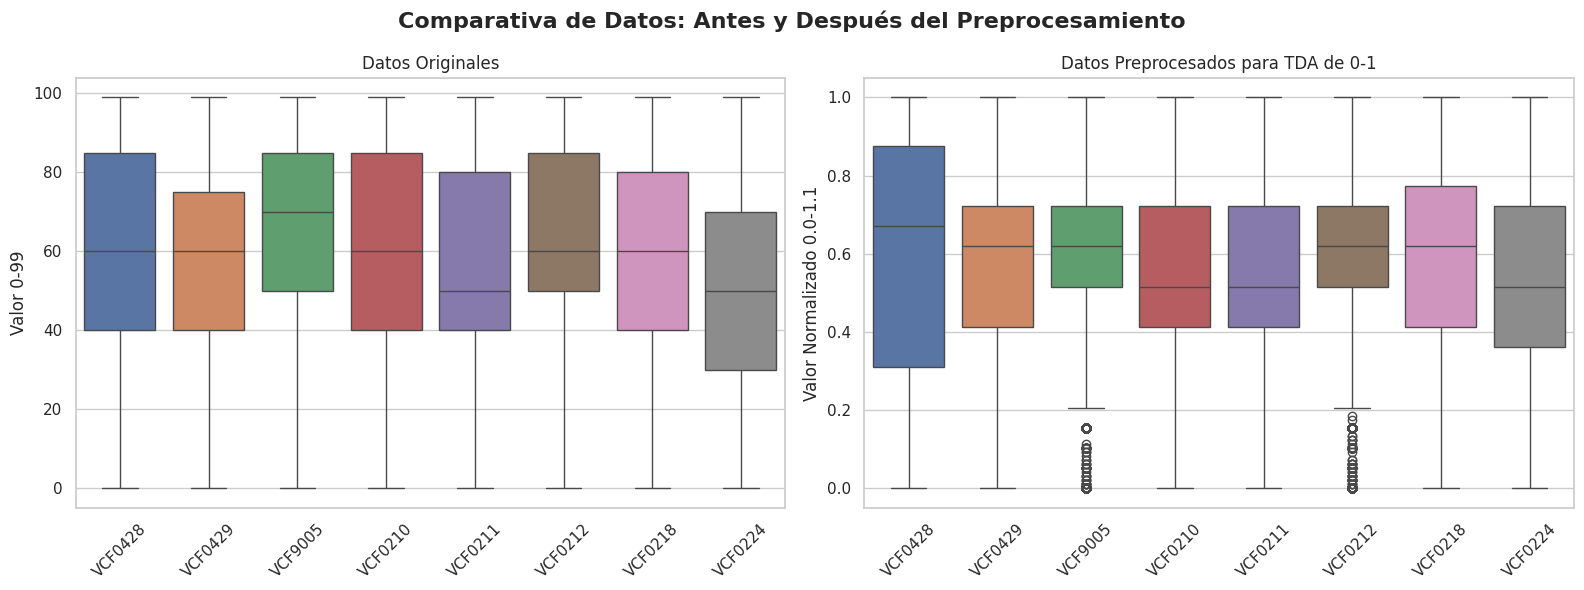

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Comenzamos Preprocesamiento")

# Seleccionamos variables: Las 8 mencionadas y el Año
columnas_deseadas = [
    'VCF0004','VCF0428', 'VCF0429', 'VCF9005','VCF0210', 'VCF0211', 'VCF0212','VCF0218', 'VCF0224'
]
#Cargamos el CSV y seleccionamos las columnas que queremos
df_raw = pd.read_csv(
    'anes_timeseries_cdf_csv_20220916.csv',
    usecols=columnas_deseadas,
    low_memory=False
)
#Cambiamos el nombre de la columna del año por "YEAR"
df_raw = df_raw.rename(columns={'VCF0004': 'YEAR'})
variables_tda = ['VCF0428', 'VCF0429', 'VCF9005', 'VCF0210', 'VCF0211', 'VCF0212', 'VCF0218', 'VCF0224']
#Dejamos las columnas en el formato que deseamos
for col in df_raw.columns:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

# Normalización
# Convertimos los códigos de error por NA
df_cleaned = df_raw.replace([98, 99], np.nan)

# Eliminamos filas incompletas
df_cleaned = df_cleaned.dropna(subset=variables_tda)

# Normalizamos las columnas a 0-1
df_tda = df_cleaned.copy()
df_tda[variables_tda] = df_tda[variables_tda] / 97.0

print(f"Filas: {len(df_tda)}")

# Creamos los gráficos de la comparación de datos crudos a limpios
sns.set_theme(style="whitegrid")
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparativa de Datos: Antes y Después del Preprocesamiento', fontsize=16, fontweight='bold')

# Gráfico de datos crudos
sns.boxplot(data=df_raw[variables_tda], ax=axs[0])
axs[0].set_title('Datos Originales')
axs[0].set_ylabel('Valor 0-99')
axs[0].tick_params(axis='x', rotation=45)

# Gráfico de datos limpios
sns.boxplot(data=df_tda[variables_tda], ax=axs[1])
axs[1].set_title('Datos Preprocesados para TDA de 0-1')
axs[1].set_ylabel('Valor Normalizado 0.0-1.1')
axs[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('Comparativa_Preprocesamiento.png', dpi=300)

# Guardamos el csv limpio
df_tda.to_csv('anes_para_tda.csv', index=False)
print("CSV limpia guardada como 'anes_para_tda.csv'")
print("Preprocesamiento finalizado")

#Algóritmo TDA

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ripser import ripser
import persim
from persim import PersistenceImager
import os

print("Comienzo del TDA")

# Creamos las carpetas para guardar los gráficos
carpetas = ['graficos_individuales', 'graficos_evolucion', 'graficos_completos_por_anio']
for carpeta in carpetas:
    os.makedirs(carpeta, exist_ok=True)

# Cargamos el CSV preprocesado. IMPORTANTE: Haber ejecutado antes el preprocesamiento
try:
    df_tda = pd.read_csv('anes_para_tda.csv')
    print("CSV cargado")
except FileNotFoundError:
    print("ERROR: No existe 'anes_para_tda.csv'. Ejecuta el archivo de preprocesamiento")
    exit()
#Analizamos los años que estan en el CSV
anios_validos = sorted(df_tda['YEAR'].unique())
print(f"Años disponibles para análisis: {anios_validos}")

# Configuramos los bloques de preguntas/variables
bloque_1 = ['VCF0428', 'VCF0429', 'VCF9005']
bloque_2 = ['VCF0210', 'VCF0211', 'VCF0212']
bloque_3 = ['VCF0218', 'VCF0224']
todas_las_variables = bloque_1 + bloque_2 + bloque_3

pimager = PersistenceImager(pixel_size=0.05)
resultados_globales = {}

# Bucle principal
for anio in anios_validos:
    df_anio = df_tda[df_tda['YEAR'] == anio]
    #No analizamos los años con menos de 50 muestras
    if len(df_anio) < 50:
        continue

    anio_int = int(anio)
    print(f"Procesando Año {anio_int} (N = {len(df_anio)})")
    resultados_globales[anio_int] = {}

    fases = {
        "Fase_1": df_anio[bloque_1].values,
        "Fase_2": df_anio[bloque_1 + bloque_2].values,
        "Fase_3": df_anio[todas_las_variables].values
    }

    # Calculamos la topología para las 3 fases del año actual
    for nombre_fase, datos_nube in fases.items():
        resultado_ripser = ripser(datos_nube, maxdim=1)
        H0 = resultado_ripser['dgms'][0]
        H1 = resultado_ripser['dgms'][1]

        H0_limpio = H0[H0[:, 1] != np.inf]

        pimager.fit([H0_limpio, H1])
        img_H0 = pimager.transform(H0_limpio)
        img_H1 = pimager.transform(H1)

        resultados_globales[anio_int][nombre_fase] = (H0_limpio, H1, img_H0, img_H1)

        # Gráficos individuales
        fig, ax = plt.subplots(figsize=(6, 6))
        persim.plot_diagrams(H0_limpio, ax=ax, title=f"Diag $H_0$ - {anio_int} ({nombre_fase})")
        plt.savefig(f"graficos_individuales/Diag_H0_{anio_int}_{nombre_fase}.png", dpi=300, bbox_inches='tight')
        plt.close()

        fig, ax = plt.subplots(figsize=(6, 6))
        persim.plot_diagrams(H1, ax=ax, title=f"Diag $H_1$ - {anio_int} ({nombre_fase})", labels=['$H_1$'])
        plt.savefig(f"graficos_individuales/Diag_H1_{anio_int}_{nombre_fase}.png", dpi=300, bbox_inches='tight')
        plt.close()

        fig, ax = plt.subplots(figsize=(6, 6))
        pimager.plot_image(img_H0, ax=ax)
        ax.set_title(f"Img $H_0$ - {anio_int} ({nombre_fase})")
        plt.savefig(f"graficos_individuales/Img_H0_{anio_int}_{nombre_fase}.png", dpi=300, bbox_inches='tight')
        plt.close()

        fig, ax = plt.subplots(figsize=(6, 6))
        pimager.plot_image(img_H1, ax=ax)
        ax.set_title(f"Img $H_1$ - {anio_int} ({nombre_fase})")
        plt.savefig(f"graficos_individuales/Img_H1_{anio_int}_{nombre_fase}.png", dpi=300, bbox_inches='tight')
        plt.close()

    # Gráfico completo anual
    fig, axs = plt.subplots(3, 4, figsize=(20, 15))
    fig.suptitle(f'Panel Completo de Evolución Topológica - Año {anio_int} (N={len(df_anio)})', fontsize=22, fontweight='bold')

    for fila, (nombre_fase, datos) in enumerate(resultados_globales[anio_int].items()):
        H0_limpio, H1, img_H0, img_H1 = datos

        # Diagrama H0
        persim.plot_diagrams(H0_limpio, ax=axs[fila, 0], title=f"{nombre_fase.replace('_', ' ')} - Diag $H_0$")
        # Diagrama H1
        persim.plot_diagrams(H1, ax=axs[fila, 1], title=f"{nombre_fase.replace('_', ' ')} - Diag $H_1$", labels=['$H_1$'])        # Imagen H0
        pimager.plot_image(img_H0, ax=axs[fila, 2])
        axs[fila, 2].set_title(f"{nombre_fase.replace('_', ' ')} - Img $H_0$")
        # Imagen H1
        pimager.plot_image(img_H1, ax=axs[fila, 3])
        axs[fila, 3].set_title(f"{nombre_fase.replace('_', ' ')} - Img $H_1$")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    nombre_archivo_completo = f"graficos_completos_por_anio/Panel_Completo_{anio_int}.png"
    plt.savefig(nombre_archivo_completo, dpi=300, bbox_inches='tight')
    plt.close()

# Graficos de evolución temporal
print("Generando gráficos de evolución temporal")
anios_procesados = list(resultados_globales.keys())
n_anios = len(anios_procesados)
nombres_fases = ["Fase_1", "Fase_2", "Fase_3"]
tipos_grafico = ["Diag_H0", "Diag_H1", "Img_H0", "Img_H1"]

for fase in nombres_fases:
    for tipo in tipos_grafico:
        fig, axs = plt.subplots(1, n_anios, figsize=(5 * n_anios, 5))
        fig.suptitle(f"Evolución Histórica: {tipo.replace('_', ' ')} - {fase.replace('_', ' ')}", fontsize=20, fontweight='bold')

        for i, anio in enumerate(anios_procesados):
            H0_limpio, H1, img_H0, img_H1 = resultados_globales[anio][fase]
            ax = axs[i]

            if tipo == "Diag_H0":
                persim.plot_diagrams(H0_limpio, ax=ax)
            elif tipo == "Diag_H1":
                persim.plot_diagrams(H1, ax=ax, labels=['$H_1$'])
            elif tipo == "Img_H0":
                pimager.plot_image(img_H0, ax=ax)
            elif tipo == "Img_H1":
                pimager.plot_image(img_H1, ax=ax)

            ax.set_title(f"Año {anio}")

        plt.tight_layout(rect=[0, 0.03, 1, 0.90])
        nombre_archivo = f"graficos_evolucion/Evolucion_{tipo}_{fase}.png"
        plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
        plt.close()

print("FIN TDA")

Comienzo del TDA
CSV cargado
Años disponibles para análisis: [np.int64(1980), np.int64(1984), np.int64(1988), np.int64(1996), np.int64(2000), np.int64(2004), np.int64(2012)]
Procesando Año 1980 (N = 1018)
Procesando Año 1984 (N = 1608)
Procesando Año 1988 (N = 1471)
Procesando Año 1996 (N = 1338)
Procesando Año 2000 (N = 1303)
Procesando Año 2004 (N = 932)
Procesando Año 2012 (N = 5098)
Generando gráficos de evolución temporal
FIN TDA


In [5]:
#Por si se quiere comprimir las carpetas de los gráficos para su posterior descarga
import shutil

shutil.make_archive('completos', 'zip', 'graficos_completos_por_anio')
shutil.make_archive('evolucion', 'zip', 'graficos_evolucion')
shutil.make_archive('individuales', 'zip', 'graficos_individuales')

'/content/individuales.zip'